# Demo 2: RAG, Function Calling, & MCP

Build a Retrieval-Augmented Generation pipeline that grounds LLM responses in actual clinical guidelines, wire up function calling so the model can take actions, then see how MCP standardizes tool integration.

## Setup

In [1]:
%pip install -q sentence-transformers chromadb openai python-dotenv mcp scikit-learn matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import json
import warnings
import numpy as np
from dotenv import load_dotenv

load_dotenv()

# Suppress noisy library warnings at the source:
# - HuggingFace progress bars and tokenizer fork warnings
# - transformers informational logging
# - chromadb resource tracker cleanup noise
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
warnings.filterwarnings("ignore", message=".*resource_tracker.*")
warnings.filterwarnings("ignore", category=FutureWarning, module="transformers")

import transformers
transformers.logging.set_verbosity_error()

from sentence_transformers import SentenceTransformer
import chromadb
from openai import OpenAI

# OpenRouter provides a unified API for many models behind an OpenAI-compatible
# endpoint. We point the standard OpenAI client at it by swapping base_url.
if os.environ.get("OPENROUTER_API_KEY"):
    client = OpenAI(
        api_key=os.environ["OPENROUTER_API_KEY"],
        base_url="https://openrouter.ai/api/v1",
    )
    MODEL = "openai/gpt-4o-mini"
elif os.environ.get("OPENAI_API_KEY"):
    client = OpenAI()
    MODEL = "gpt-4o-mini"
else:
    raise ValueError("Set OPENROUTER_API_KEY or OPENAI_API_KEY in .env")

print(f"Using model: {MODEL}")

Using model: openai/gpt-4o-mini


## Section 1: Clinical Knowledge Base

Synthetic clinical guideline chunks — the kind of documents a hospital might want an LLM to reference when answering clinical questions. Each chunk has an id, the text content, and a source attribution. In production these would come from splitting real guideline PDFs into overlapping passages.

In [3]:
clinical_knowledge = [
    {
        "id": "hypertension_1",
        "text": "Stage 1 hypertension is defined as systolic blood pressure 130-139 mmHg or diastolic 80-89 mmHg. Initial treatment includes lifestyle modifications: weight loss, DASH diet, sodium restriction (<2300mg/day), regular exercise (150 min/week moderate intensity).",
        "source": "JNC8 Guidelines"
    },
    {
        "id": "hypertension_2",
        "text": "First-line antihypertensive medications include thiazide diuretics, ACE inhibitors, ARBs, and calcium channel blockers. Choice depends on comorbidities: ACE inhibitors or ARBs preferred in diabetes and chronic kidney disease.",
        "source": "JNC8 Guidelines"
    },
    {
        "id": "diabetes_1",
        "text": "Type 2 diabetes is diagnosed with fasting glucose ≥126 mg/dL, HbA1c ≥6.5%, or 2-hour glucose ≥200 mg/dL during OGTT. Metformin is first-line therapy unless contraindicated. Target HbA1c <7% for most adults.",
        "source": "ADA Standards of Care"
    },
    {
        "id": "diabetes_2",
        "text": "For patients with type 2 diabetes and cardiovascular disease, SGLT2 inhibitors or GLP-1 receptor agonists with proven cardiovascular benefit are recommended regardless of HbA1c. Examples: empagliflozin, liraglutide.",
        "source": "ADA Standards of Care"
    },
    {
        "id": "chest_pain_1",
        "text": "Acute chest pain evaluation: HEART score assesses History, ECG, Age, Risk factors, and Troponin. Score 0-3 is low risk (discharge with follow-up), 4-6 is intermediate (admit for observation), 7-10 is high risk (early invasive strategy).",
        "source": "AHA Chest Pain Guidelines"
    },
    {
        "id": "chest_pain_2",
        "text": "STEMI diagnosis requires ST elevation ≥1mm in 2 contiguous leads or new LBBB with symptoms. Door-to-balloon time goal <90 minutes for primary PCI. If PCI not available within 120 minutes, fibrinolysis within 30 minutes.",
        "source": "AHA Chest Pain Guidelines"
    },
]

print(f"{len(clinical_knowledge)} guideline chunks loaded")
for doc in clinical_knowledge:
    print(f"  [{doc['source']}] {doc['text'][:60]}...")

6 guideline chunks loaded
  [JNC8 Guidelines] Stage 1 hypertension is defined as systolic blood pressure 1...
  [JNC8 Guidelines] First-line antihypertensive medications include thiazide diu...
  [ADA Standards of Care] Type 2 diabetes is diagnosed with fasting glucose ≥126 mg/dL...
  [ADA Standards of Care] For patients with type 2 diabetes and cardiovascular disease...
  [AHA Chest Pain Guidelines] Acute chest pain evaluation: HEART score assesses History, E...
  [AHA Chest Pain Guidelines] STEMI diagnosis requires ST elevation ≥1mm in 2 contiguous l...


## Section 2: Embedding & ChromaDB Indexing

An embedding is a fixed-length numeric vector that captures the *meaning* of a text chunk — similar documents end up near each other in vector space. ChromaDB is an in-memory vector database: we encode each chunk into an embedding, store them, and later retrieve the closest matches to a query.

In [4]:
# all-MiniLM-L6-v2: a small (22M param) model that maps text → 384-dim vectors.
# Runs locally on CPU — no API call needed for embedding.
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# ChromaDB stores vectors in-memory. In production you'd use a persistent store.
chroma_client = chromadb.Client()
collection = chroma_client.create_collection(
    name="clinical_guidelines",
    metadata={"description": "Clinical practice guidelines"},
)

# Prepare parallel lists: ChromaDB expects documents, ids, metadata, and embeddings
# to line up by index.
documents = [doc["text"] for doc in clinical_knowledge]
ids = [doc["id"] for doc in clinical_knowledge]
metadatas = [{"source": doc["source"]} for doc in clinical_knowledge]

# encode() runs the text through the model and returns a numpy array of shape
# (n_documents, 384). We convert to list for ChromaDB.
embeddings = embedding_model.encode(documents).tolist()

collection.add(
    documents=documents,
    ids=ids,
    metadatas=metadatas,
    embeddings=embeddings,
)

print(f"Indexed {collection.count()} chunks in ChromaDB")
print(f"Embedding dimension: {len(embeddings[0])}")
print(f"\nFirst embedding (truncated): [{', '.join(f'{x:.4f}' for x in embeddings[0][:8])}, ...]")

Indexed 6 chunks in ChromaDB
Embedding dimension: 384

First embedding (truncated): [-0.0254, 0.0779, -0.0609, -0.0790, -0.0819, -0.0206, -0.0450, -0.0067, ...]


Each chunk is now a 384-dimensional vector. Chunks about similar topics should be close together in that space — let's verify with a similarity heatmap:

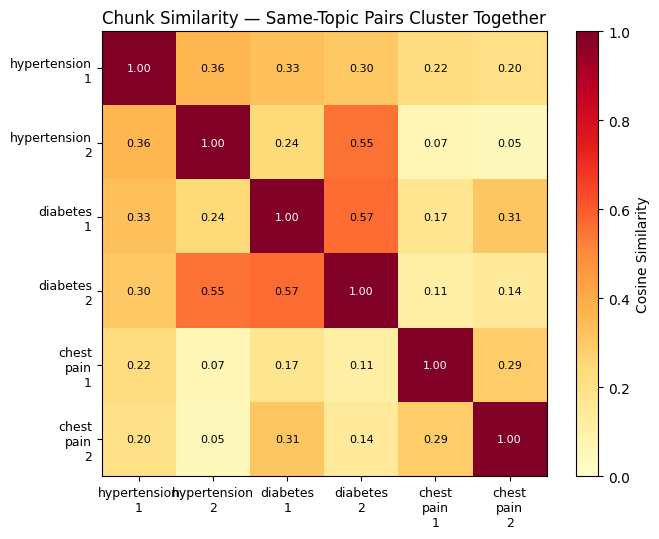

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# Cosine similarity: 1.0 = identical meaning, 0.0 = unrelated
sim_matrix = cosine_similarity(embeddings)
labels = [doc["id"].replace("_", "\n") for doc in clinical_knowledge]

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(sim_matrix, cmap="YlOrRd", vmin=0, vmax=1)
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=9)
ax.set_yticklabels(labels, fontsize=9)

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{sim_matrix[i][j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if sim_matrix[i][j] > 0.6 else "black")

fig.colorbar(im, ax=ax, label="Cosine Similarity")
ax.set_title("Chunk Similarity — Same-Topic Pairs Cluster Together")
plt.tight_layout()
plt.show()

The hypertension chunks are most similar to each other, the diabetes chunks cluster, and the chest pain chunks cluster. This is what makes retrieval work — a question about hypertension will land near the hypertension chunks in vector space.

## Section 3: RAG Query Function

The core RAG loop: embed the question → retrieve similar chunks → inject them as context → generate a grounded answer. The `n_results` parameter controls how many chunks to retrieve (more context = more information but also more noise and cost). The system prompt constrains the model to answer *only* from provided context — this is what makes RAG grounded rather than generative.

In [6]:
def rag_query(question, n_results=3, show_sources=True):
    """Answer a question using retrieved guideline chunks as context."""

    # RETRIEVE: embed the question with the same model used for documents,
    # then find the n closest chunks by cosine distance
    query_embedding = embedding_model.encode([question]).tolist()
    results = collection.query(
        query_embeddings=query_embedding,
        n_results=n_results,
        include=["documents", "metadatas", "distances"],
    )

    if show_sources:
        print("Retrieved documents:")
        for i, (doc, meta, dist) in enumerate(zip(
            results["documents"][0],
            results["metadatas"][0],
            results["distances"][0],
        )):
            print(f"  {i+1}. [{meta['source']}] (distance: {dist:.3f})")
            print(f"     {doc[:80]}...")
        print()

    # AUGMENT: concatenate retrieved chunks into a single context block
    context = "\n\n".join(results["documents"][0])

    # GENERATE: the system prompt constrains the model to only use
    # the provided context — no training-data knowledge allowed
    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {
                "role": "system",
                "content": (
                    "You are a clinical assistant. Answer based ONLY on the provided context. "
                    "If the context doesn't contain enough information, say so. "
                    "Cite the guideline source when possible."
                ),
            },
            {"role": "user", "content": f"Context:\n{context}\n\nQuestion: {question}"},
        ],
        temperature=0,
        max_tokens=500,
    )
    return response.choices[0].message.content

In [7]:
questions = [
    "What is the first-line treatment for hypertension in a patient with diabetes?",
    "How do I evaluate a patient with acute chest pain?",
    "What HbA1c level indicates diabetes?",
]

for q in questions:
    print("=" * 60)
    print(f"Q: {q}\n")
    answer = rag_query(q)
    print(f"A: {answer}\n")

Q: What is the first-line treatment for hypertension in a patient with diabetes?

Retrieved documents:
  1. [JNC8 Guidelines] (distance: 0.631)
     First-line antihypertensive medications include thiazide diuretics, ACE inhibito...
  2. [JNC8 Guidelines] (distance: 0.927)
     Stage 1 hypertension is defined as systolic blood pressure 130-139 mmHg or diast...
  3. [ADA Standards of Care] (distance: 0.936)
     For patients with type 2 diabetes and cardiovascular disease, SGLT2 inhibitors o...



A: The first-line treatment for hypertension in a patient with diabetes includes ACE inhibitors or ARBs, as they are preferred in this population.

Q: How do I evaluate a patient with acute chest pain?

Retrieved documents:
  1. [AHA Chest Pain Guidelines] (distance: 0.645)
     Acute chest pain evaluation: HEART score assesses History, ECG, Age, Risk factor...
  2. [AHA Chest Pain Guidelines] (distance: 1.489)
     STEMI diagnosis requires ST elevation ≥1mm in 2 contiguous leads or new LBBB wit...
  3. [JNC8 Guidelines] (distance: 1.736)
     First-line antihypertensive medications include thiazide diuretics, ACE inhibito...



A: To evaluate a patient with acute chest pain, you can use the HEART score, which assesses the following components:

1. **History**: Evaluate the patient's history of chest pain.
2. **ECG**: Perform an electrocardiogram to check for abnormalities.
3. **Age**: Consider the patient's age as a risk factor.
4. **Risk factors**: Assess for traditional cardiovascular risk factors (e.g., smoking, hypertension, diabetes).
5. **Troponin**: Measure troponin levels to check for myocardial injury.

Based on the HEART score, you can categorize the risk:
- **Score 0-3**: Low risk (discharge with follow-up).
- **Score 4-6**: Intermediate risk (admit for observation).
- **Score 7-10**: High risk (consider an early invasive strategy).

Additionally, if you suspect STEMI, look for ST elevation ≥1mm in 2 contiguous leads or new left bundle branch block (LBBB) with symptoms. Ensure that the door-to-balloon time for primary PCI is less than 90 minutes, and if PCI is not available within 120 minutes, init

A: An HbA1c level of ≥6.5% indicates diabetes.



Lower distance = higher semantic similarity. The model stays grounded because the system prompt constrains it to the retrieved context, and it can cite guideline sources because that metadata was stored alongside the embeddings.

## Section 4: RAG vs Direct LLM

What happens when the model answers *without* retrieved context? For well-known clinical facts (like hypertension thresholds) the LLM may already know the answer — but for organization-specific protocols, recent guideline updates, or internal policy, the model has no choice but to guess or refuse. RAG grounds responses in retrieved documents, reducing hallucination and making outputs verifiable.

In [8]:
def direct_llm_query(question):
    """Ask the LLM directly — no retrieval, no grounding context."""
    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": "You are a clinical assistant. Be concise."},
            {"role": "user", "content": question},
        ],
        temperature=0,
        max_tokens=500,
    )
    return response.choices[0].message.content


# The HEART score thresholds are a good test case: exact cutoffs vary by
# institutional protocol. Our guidelines say 0-3/4-6/7-10 — the LLM's
# training data may use different cutoffs.
test_q = (
    "According to the AHA Chest Pain Guidelines, what HEART score threshold "
    "separates low-risk from intermediate-risk patients, and what is the recommended "
    "action for each risk category?"
)

print("RAG Response (grounded in our guidelines):")
rag_answer = rag_query(test_q)
print(rag_answer)
print("\n" + "-" * 40 + "\n")
print("Direct LLM Response (from training data — may differ or hallucinate thresholds):")
print(direct_llm_query(test_q))

RAG Response (grounded in our guidelines):
Retrieved documents:
  1. [AHA Chest Pain Guidelines] (distance: 0.488)
     Acute chest pain evaluation: HEART score assesses History, ECG, Age, Risk factor...
  2. [JNC8 Guidelines] (distance: 1.290)
     Stage 1 hypertension is defined as systolic blood pressure 130-139 mmHg or diast...
  3. [AHA Chest Pain Guidelines] (distance: 1.509)
     STEMI diagnosis requires ST elevation ≥1mm in 2 contiguous leads or new LBBB wit...



According to the AHA Chest Pain Guidelines, a HEART score of 0-3 separates low-risk patients from those at intermediate risk (score of 4-6). The recommended action for low-risk patients is to discharge them with follow-up, while for intermediate-risk patients, the recommendation is to admit them for observation.

----------------------------------------

Direct LLM Response (from training data — may differ or hallucinate thresholds):


According to the AHA Chest Pain Guidelines, a HEART score of 0-3 indicates low risk, while a score of 4-6 indicates intermediate risk. 

- **Low-risk (HEART score 0-3)**: Recommended action is to consider discharge with appropriate follow-up and reassurance.
- **Intermediate-risk (HEART score 4-6)**: Recommended action is to consider further diagnostic testing and observation.


## Section 5: RAG with Citations

In clinical contexts, knowing *where* an answer came from is as important as the answer itself — a clinician needs to verify claims against the original guideline, not just trust the model. Numbering source chunks and instructing the model to cite them makes every claim traceable.

In [9]:
def rag_with_citations(question, n_results=3):
    """RAG that returns answer + numbered source citations."""
    query_embedding = embedding_model.encode([question]).tolist()
    results = collection.query(
        query_embeddings=query_embedding,
        n_results=n_results,
        include=["documents", "metadatas"],
    )

    # Number each source so the model can reference them as [1], [2], etc.
    context_parts = []
    sources = []
    for i, (doc, meta) in enumerate(
        zip(results["documents"][0], results["metadatas"][0])
    ):
        context_parts.append(f"[{i+1}] {doc}")
        sources.append(f"[{i+1}] {meta['source']}")

    context = "\n\n".join(context_parts)

    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {
                "role": "system",
                "content": (
                    "Answer based on the numbered sources. "
                    "Include citation numbers [1], [2], etc."
                ),
            },
            {"role": "user", "content": f"Sources:\n{context}\n\nQuestion: {question}"},
        ],
        temperature=0,
        max_tokens=500,
    )

    return {"answer": response.choices[0].message.content, "sources": sources}


result = rag_with_citations(
    "What medications are recommended for diabetic patients with heart disease?"
)
print(f"Answer: {result['answer']}\n")
print("Sources:")
for s in result["sources"]:
    print(f"  {s}")

Answer: For patients with type 2 diabetes who also have cardiovascular disease, it is recommended to use SGLT2 inhibitors or GLP-1 receptor agonists that have proven cardiovascular benefits, regardless of their HbA1c levels. Examples of these medications include empagliflozin and liraglutide [1].

Sources:
  [1] ADA Standards of Care
  [2] JNC8 Guidelines
  [3] ADA Standards of Care


## Section 6: Function Calling — Letting the Model Use Tools

RAG retrieves documents. But what if the model needs to *do* something — look up a drug interaction, calculate a dose, check lab values? **Function calling** lets you define tools as JSON schemas, pass them to the model, and let it decide when to invoke them.

The `tools` parameter serves two purposes:

- **Tool use**: the model *chooses* to call a function based on the conversation
- **Structured output**: you *force* the model to return data matching a schema

The model never executes code — it generates a JSON object with the function name and arguments. Your code runs the actual function and feeds the result back.

In [10]:
# Tool definitions follow the OpenAI function calling format:
# - "name" and "description" tell the model what the tool does
# - "parameters" is a JSON Schema defining expected arguments
# The model reads these schemas and decides when/how to call each tool.
tools = [
    {
        "type": "function",
        "function": {
            "name": "check_drug_interaction",
            "description": "Check for known interactions between two medications. Returns severity and clinical advice.",
            "parameters": {
                "type": "object",
                "properties": {
                    "drug_a": {"type": "string", "description": "First medication name"},
                    "drug_b": {"type": "string", "description": "Second medication name"},
                },
                "required": ["drug_a", "drug_b"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "calculate_egfr",
            "description": "Calculate estimated GFR using the CKD-EPI equation. Used to assess kidney function before prescribing.",
            "parameters": {
                "type": "object",
                "properties": {
                    "creatinine": {"type": "number", "description": "Serum creatinine in mg/dL"},
                    "age": {"type": "integer", "description": "Patient age in years"},
                    "sex": {"type": "string", "enum": ["male", "female"], "description": "Biological sex"},
                },
                "required": ["creatinine", "age", "sex"],
            },
        },
    },
]

print(f"Defined {len(tools)} tools for the model:")
for t in tools:
    print(f"  - {t['function']['name']}: {t['function']['description'][:70]}...")

Defined 2 tools for the model:
  - check_drug_interaction: Check for known interactions between two medications. Returns severity...
  - calculate_egfr: Calculate estimated GFR using the CKD-EPI equation. Used to assess kid...


Now we define the actual Python functions that execute when the model requests a tool call. In production these would hit a real drug database or clinical calculator API — here we use lookup tables.

In [11]:
# Simulated drug interaction database — in production this would query
# a real pharmacy database (e.g., DrugBank, First Databank)
INTERACTION_DB = {
    ("metformin", "contrast"): {
        "severity": "high",
        "description": "Hold metformin 48h before/after iodinated contrast — risk of lactic acidosis",
    },
    ("warfarin", "aspirin"): {
        "severity": "high",
        "description": "Increased bleeding risk — monitor INR closely, consider GI prophylaxis",
    },
    ("ace inhibitor", "potassium"): {
        "severity": "moderate",
        "description": "Risk of hyperkalemia — monitor serum potassium regularly",
    },
    ("lisinopril", "spironolactone"): {
        "severity": "moderate",
        "description": "Both raise potassium — monitor K+ levels, risk of hyperkalemia",
    },
}


def check_drug_interaction(drug_a: str, drug_b: str) -> str:
    """Look up known interactions between two drugs."""
    a, b = drug_a.lower().strip(), drug_b.lower().strip()
    result = INTERACTION_DB.get((a, b)) or INTERACTION_DB.get((b, a))
    if result:
        return json.dumps(result)
    return json.dumps({"severity": "none", "description": f"No known interaction between {drug_a} and {drug_b}"})


def calculate_egfr(creatinine: float, age: int, sex: str) -> str:
    """CKD-EPI 2021 equation (race-free). Returns eGFR in mL/min/1.73m²."""
    if sex == "female":
        kappa, alpha, multiplier = 0.7, -0.241, 142 * 1.012
    else:
        kappa, alpha, multiplier = 0.9, -0.302, 142
    scr_ratio = creatinine / kappa
    egfr = multiplier * (min(scr_ratio, 1) ** alpha) * (max(scr_ratio, 1) ** -1.200) * (0.9938 ** age)
    return json.dumps({"egfr": round(egfr, 1), "unit": "mL/min/1.73m²"})


# Dispatcher: maps tool name strings to Python functions
TOOL_DISPATCH = {
    "check_drug_interaction": check_drug_interaction,
    "calculate_egfr": calculate_egfr,
}

# Quick sanity check
print("Drug interaction test:")
print(f"  warfarin + aspirin → {check_drug_interaction('warfarin', 'aspirin')}")
print(f"\neGFR test:")
print(f"  creatinine=1.2, age=65, male → {calculate_egfr(1.2, 65, 'male')}")

Drug interaction test:
  warfarin + aspirin → {"severity": "high", "description": "Increased bleeding risk \u2014 monitor INR closely, consider GI prophylaxis"}

eGFR test:
  creatinine=1.2, age=65, male → {"egfr": 67.1, "unit": "mL/min/1.73m\u00b2"}


### The Full Tool Call Loop

This is the core pattern: send the conversation with tool definitions → model decides to call a tool → we execute it → feed the result back → model generates a final response incorporating the tool output.

In [12]:
def clinical_assistant(question):
    """
    Clinical assistant with tool access. Implements the complete function
    calling loop: prompt → tool call → execute → respond.
    """
    messages = [
        {
            "role": "system",
            "content": (
                "You are a clinical pharmacist assistant. Use the provided tools "
                "to check drug interactions and calculate kidney function when relevant. "
                "Always check interactions before recommending combination therapy."
            ),
        },
        {"role": "user", "content": question},
    ]

    # Step 1: Send the message with tool definitions.
    # The model may respond directly OR request one or more tool calls.
    response = client.chat.completions.create(
        model=MODEL,
        messages=messages,
        tools=tools,
        tool_choice="auto",  # model decides whether to use tools
        temperature=0,
    )

    assistant_msg = response.choices[0].message

    # Step 2: If the model didn't request any tools, return the direct answer
    if not assistant_msg.tool_calls:
        print("[No tools called — model answered directly]")
        return assistant_msg.content

    # Step 3: Execute each tool the model requested and collect results.
    # The assistant message with tool_calls must stay in the conversation
    # so the model knows what it asked for.
    messages.append(assistant_msg)

    for tool_call in assistant_msg.tool_calls:
        fn_name = tool_call.function.name
        fn_args = json.loads(tool_call.function.arguments)

        print(f"[Tool call: {fn_name}({fn_args})]")

        # Dispatch to the actual Python function
        result = TOOL_DISPATCH[fn_name](**fn_args)

        print(f"[Tool result: {result}]")

        # Feed the result back as a "tool" role message, keyed by tool_call_id
        # so the model knows which call this result corresponds to
        messages.append({
            "role": "tool",
            "tool_call_id": tool_call.id,
            "content": result,
        })

    # Step 4: Send the updated conversation (now including tool results)
    # back to the model for a final natural-language response.
    final_response = client.chat.completions.create(
        model=MODEL,
        messages=messages,
        tools=tools,
        temperature=0,
    )

    return final_response.choices[0].message.content

In [13]:
# Test 1: Should trigger a drug interaction check
print("=" * 60)
q1 = "Is it safe to prescribe warfarin and aspirin together?"
print(f"Q: {q1}\n")
print(f"A: {clinical_assistant(q1)}\n")

# Test 2: Should trigger eGFR calculation
print("=" * 60)
q2 = "A 65-year-old male patient has a creatinine of 1.8 mg/dL. What is his kidney function?"
print(f"Q: {q2}\n")
print(f"A: {clinical_assistant(q2)}\n")

# Test 3: Doesn't need tools — model should answer directly
print("=" * 60)
q3 = "What are the common side effects of metformin?"
print(f"Q: {q3}\n")
print(f"A: {clinical_assistant(q3)}")

Q: Is it safe to prescribe warfarin and aspirin together?



[Tool call: check_drug_interaction({'drug_a': 'warfarin', 'drug_b': 'aspirin'})]
[Tool result: {"severity": "high", "description": "Increased bleeding risk \u2014 monitor INR closely, consider GI prophylaxis"}]


A: Prescribing warfarin and aspirin together is associated with a high risk of increased bleeding. It is important to monitor the INR closely and consider gastrointestinal prophylaxis to mitigate this risk.

Q: A 65-year-old male patient has a creatinine of 1.8 mg/dL. What is his kidney function?



[Tool call: calculate_egfr({'creatinine': 1.8, 'age': 65, 'sex': 'male'})]
[Tool result: {"egfr": 41.3, "unit": "mL/min/1.73m\u00b2"}]


A: The estimated glomerular filtration rate (eGFR) for the 65-year-old male patient with a creatinine level of 1.8 mg/dL is approximately 41.3 mL/min/1.73m². This indicates moderate kidney impairment.

Q: What are the common side effects of metformin?



[No tools called — model answered directly]
A: Common side effects of metformin include:

1. **Gastrointestinal Issues**: 
   - Nausea
   - Vomiting
   - Diarrhea
   - Stomach upset or pain
   - Loss of appetite

2. **Metallic Taste**: Some patients may experience a metallic taste in their mouth.

3. **Lactic Acidosis**: Although rare, this is a serious condition that can occur, especially in patients with kidney problems.

4. **Vitamin B12 Deficiency**: Long-term use of metformin may lead to decreased absorption of vitamin B12.

5. **Hypoglycemia**: While metformin alone does not usually cause low blood sugar, it can contribute to hypoglycemia when used in combination with other diabetes medications.

Most side effects are mild and often improve over time. However, if any severe side effects or symptoms of lactic acidosis (such as unusual muscle pain, difficulty breathing, or feeling cold) occur, medical attention should be sought immediately.


The model reads the tool schemas, decides which to call based on the question, and generates arguments matching the JSON schema. Our code executes the function and feeds the result back. The model never runs code itself — function calling is a structured handoff protocol.

### Structured Output via Function Calling

Function calling has a second use: forcing the model to return data matching a specific schema. Instead of hoping the model formats JSON correctly (prompt-based), you define a "tool" that represents your desired output structure and set `tool_choice` to force the model to "call" it. The model returns arguments matching the schema — guaranteed structured output.

In [14]:
from enum import Enum
from pydantic import BaseModel


# Pydantic model mirrors the JSON Schema we'll send to the API.
# After we get the model's response, we parse into this model —
# if any field is missing, wrong type, or outside the enum, validation fails.
class Severity(str, Enum):
    mild = "mild"
    moderate = "moderate"
    severe = "severe"


class ClinicalAssessment(BaseModel):
    diagnosis: str
    severity: Severity
    medications: list[str]
    follow_up_days: int


# The tool schema tells the API what structure to produce.
# The Pydantic model validates the result on our side.
structured_output_tool = {
    "type": "function",
    "function": {
        "name": "record_assessment",
        "description": "Record a structured clinical assessment for a patient.",
        "parameters": {
            "type": "object",
            "properties": {
                "diagnosis": {"type": "string", "description": "Primary diagnosis"},
                "severity": {
                    "type": "string",
                    "enum": ["mild", "moderate", "severe"],
                    "description": "Severity classification",
                },
                "medications": {
                    "type": "array",
                    "items": {"type": "string"},
                    "description": "Recommended medications",
                },
                "follow_up_days": {
                    "type": "integer",
                    "description": "Days until follow-up appointment",
                },
            },
            "required": ["diagnosis", "severity", "medications", "follow_up_days"],
        },
    },
}

# tool_choice forces the model to "call" this function — it can't return
# freeform text, only arguments matching the schema
response = client.chat.completions.create(
    model=MODEL,
    messages=[
        {
            "role": "system",
            "content": "You are a clinical assistant. Assess the patient and record a structured assessment.",
        },
        {
            "role": "user",
            "content": (
                "Patient presents with blood pressure 145/92 mmHg on two separate visits. "
                "No diabetes, no kidney disease. BMI 28. Currently on no medications."
            ),
        },
    ],
    tools=[structured_output_tool],
    tool_choice={"type": "function", "function": {"name": "record_assessment"}},
    temperature=0,
)

# Extract the raw JSON, then validate with Pydantic.
# If the model returned "severity": "critical" or omitted a field,
# this would raise a ValidationError instead of silently passing bad data.
raw = json.loads(response.choices[0].message.tool_calls[0].function.arguments)
assessment = ClinicalAssessment(**raw)

print("Structured clinical assessment (validated):\n")
print(json.dumps(raw, indent=2))
print(f"\nDiagnosis:    {assessment.diagnosis}")
print(f"Severity:     {assessment.severity.value}")
print(f"Medications:  {', '.join(assessment.medications)}")
print(f"Follow-up:    {assessment.follow_up_days} days")
print(f"\nPydantic type: {type(assessment).__name__} ✓")

Structured clinical assessment (validated):

{
  "diagnosis": "Hypertension",
  "severity": "moderate",
  "medications": [
    "Lisinopril",
    "Amlodipine"
  ],
  "follow_up_days": 30
}

Diagnosis:    Hypertension
Severity:     moderate
Medications:  Lisinopril, Amlodipine
Follow-up:    30 days

Pydantic type: ClinicalAssessment ✓


Two layers of enforcement: the API's `tool_choice` constrains what the model generates, and Pydantic validates what we actually received. The JSON Schema defines the contract, Pydantic enforces it at runtime.

## Section 7: MCP — Standardized Tool Integration

Function calling works, but every integration is custom: you define schemas by hand, write dispatch logic, manage connections per tool. **MCP** (Model Context Protocol) standardizes this — define tools once on a server, and any MCP-compatible client can discover and use them automatically.

An MCP server is a process that exposes tools via a standard protocol. The `@mcp.tool()` decorator + type hints handle schema generation — no manual JSON schema needed.

In [15]:
# Write a self-contained MCP server to a file. In production this would be
# a long-running service; here we launch it as a subprocess for the demo.
server_code = '''\
from mcp.server.fastmcp import FastMCP

mcp = FastMCP("Clinical Tools")


@mcp.tool()
def check_drug_interaction(drug_a: str, drug_b: str) -> str:
    """Check for known interactions between two medications.
    Returns severity level and clinical recommendation."""
    interactions = {
        ("metformin", "contrast"): "HIGH: Hold metformin 48h before/after contrast",
        ("warfarin", "aspirin"): "HIGH: Increased bleeding risk, monitor INR",
        ("lisinopril", "spironolactone"): "MODERATE: Hyperkalemia risk, monitor K+",
    }
    a, b = drug_a.lower().strip(), drug_b.lower().strip()
    result = interactions.get((a, b)) or interactions.get((b, a))
    return result or f"No known interaction between {drug_a} and {drug_b}"


@mcp.tool()
def calculate_bmi(weight_kg: float, height_m: float) -> str:
    """Calculate BMI from weight in kg and height in meters."""
    bmi = weight_kg / (height_m ** 2)
    category = (
        "underweight" if bmi < 18.5
        else "normal" if bmi < 25
        else "overweight" if bmi < 30
        else "obese"
    )
    return f"BMI: {bmi:.1f} ({category})"


@mcp.tool()
def calculate_egfr(creatinine: float, age: int, sex: str) -> str:
    """Estimate glomerular filtration rate (CKD-EPI 2021, race-free).
    creatinine in mg/dL, age in years, sex is male or female."""
    if sex == "female":
        kappa, alpha, mult = 0.7, -0.241, 142 * 1.012
    else:
        kappa, alpha, mult = 0.9, -0.302, 142
    ratio = creatinine / kappa
    egfr = mult * (min(ratio, 1) ** alpha) * (max(ratio, 1) ** -1.200) * (0.9938 ** age)
    return f"eGFR: {egfr:.1f} mL/min/1.73m2"


if __name__ == "__main__":
    mcp.run()
'''

server_path = "clinical_mcp_server.py"
with open(server_path, "w") as f:
    f.write(server_code)

print(f"Wrote MCP server to {server_path}")
print("Server exposes 3 tools: check_drug_interaction, calculate_bmi, calculate_egfr")

Wrote MCP server to clinical_mcp_server.py
Server exposes 3 tools: check_drug_interaction, calculate_bmi, calculate_egfr


### MCP Client: Discovering and Calling Tools

The MCP client connects to a server process, discovers available tools automatically, and can call them. The key advantage over manual function calling: tool schemas are generated from type hints and docstrings on the server side, not maintained separately by the client.

In [16]:
import asyncio
from mcp import ClientSession, StdioServerParameters
from mcp.client.stdio import stdio_client


async def discover_and_call_tools():
    """Connect to our MCP server, list its tools, and call one."""

    # StdioServerParameters tells the client how to launch the server process.
    # The server communicates via stdin/stdout (the "stdio" transport).
    server_params = StdioServerParameters(
        command="python",
        args=[server_path],
    )

    # stdio_client manages the server subprocess lifecycle
    async with stdio_client(server_params) as (read_stream, write_stream):
        async with ClientSession(read_stream, write_stream) as session:
            await session.initialize()

            # DISCOVER: list all tools the server exposes
            tools_result = await session.list_tools()
            print(f"Discovered {len(tools_result.tools)} tools:\n")
            for tool in tools_result.tools:
                print(f"  {tool.name}: {tool.description[:70]}...")
                params = tool.inputSchema.get("properties", {})
                param_str = ", ".join(f"{k}: {v.get('type', '?')}" for k, v in params.items())
                print(f"    Parameters: ({param_str})\n")

            # CALL: invoke tools through the MCP protocol
            print("-" * 40)
            print("Calling check_drug_interaction('warfarin', 'aspirin'):")
            result = await session.call_tool(
                "check_drug_interaction",
                arguments={"drug_a": "warfarin", "drug_b": "aspirin"},
            )
            print(f"  → {result.content[0].text}")

            print("\nCalling calculate_bmi(weight_kg=82, height_m=1.75):")
            result = await session.call_tool(
                "calculate_bmi",
                arguments={"weight_kg": 82, "height_m": 1.75},
            )
            print(f"  → {result.content[0].text}")

            print("\nCalling calculate_egfr(creatinine=1.2, age=65, sex='male'):")
            result = await session.call_tool(
                "calculate_egfr",
                arguments={"creatinine": 1.2, "age": 65, "sex": "male"},
            )
            print(f"  → {result.content[0].text}")


# Jupyter already runs an event loop, so we use await directly
await discover_and_call_tools()

Discovered 3 tools:

  check_drug_interaction: Check for known interactions between two medications.
    Returns seve...
    Parameters: (drug_a: string, drug_b: string)

  calculate_bmi: Calculate BMI from weight in kg and height in meters....
    Parameters: (weight_kg: number, height_m: number)

  calculate_egfr: Estimate glomerular filtration rate (CKD-EPI 2021, race-free).
    cre...
    Parameters: (creatinine: number, age: integer, sex: string)

----------------------------------------
Calling check_drug_interaction('warfarin', 'aspirin'):
  → HIGH: Increased bleeding risk, monitor INR

Calling calculate_bmi(weight_kg=82, height_m=1.75):
  → BMI: 26.8 (overweight)

Calling calculate_egfr(creatinine=1.2, age=65, sex='male'):
  → eGFR: 67.1 mL/min/1.73m2


### MCP Tool Schemas → OpenAI Function Calling

MCP tools generate JSON schemas from Python type hints. These schemas are directly compatible with OpenAI's function calling format — you can bridge MCP discovery into any LLM that supports tool use.

In [17]:
async def mcp_tools_to_openai_format():
    """Fetch MCP tool schemas and convert to OpenAI function calling format."""
    server_params = StdioServerParameters(command="python", args=[server_path])

    async with stdio_client(server_params) as (read_stream, write_stream):
        async with ClientSession(read_stream, write_stream) as session:
            await session.initialize()
            tools_result = await session.list_tools()

            # Convert MCP tool definitions → OpenAI tools format.
            # MCP's inputSchema IS a JSON Schema object, so it maps directly
            # to the "parameters" field in OpenAI's function calling spec.
            openai_tools = []
            for tool in tools_result.tools:
                openai_tools.append({
                    "type": "function",
                    "function": {
                        "name": tool.name,
                        "description": tool.description,
                        "parameters": tool.inputSchema,
                    },
                })

            return openai_tools


openai_format_tools = await mcp_tools_to_openai_format()

print("MCP tools converted to OpenAI function calling format:\n")
for t in openai_format_tools:
    fn = t["function"]
    params = fn["parameters"].get("properties", {})
    param_str = ", ".join(f"{k} ({v.get('type', '?')})" for k, v in params.items())
    print(f"  {fn['name']}({param_str})")
    print(f"    {fn['description'][:80]}")
    print()

print("These can be passed directly to client.chat.completions.create(tools=...)")

MCP tools converted to OpenAI function calling format:

  check_drug_interaction(drug_a (string), drug_b (string))
    Check for known interactions between two medications.
    Returns severity level

  calculate_bmi(weight_kg (number), height_m (number))
    Calculate BMI from weight in kg and height in meters.

  calculate_egfr(creatinine (number), age (integer), sex (string))
    Estimate glomerular filtration rate (CKD-EPI 2021, race-free).
    creatinine in

These can be passed directly to client.chat.completions.create(tools=...)


MCP servers expose tools via a standard protocol. Any MCP client — Claude Code, Cursor, ChatGPT, or your own code — can discover and use them without writing custom integration logic. The schemas are generated from Python type hints on the server, converted to JSON Schema by MCP, and consumed as function calling definitions by the LLM.

In [18]:
# Clean up the temporary server file
os.remove(server_path)
print(f"Cleaned up {server_path}")

Cleaned up clinical_mcp_server.py
